In [1]:
import numpy as np
import pandas as pd
import MDAnalysis as mda
import matplotlib.pyplot as plt

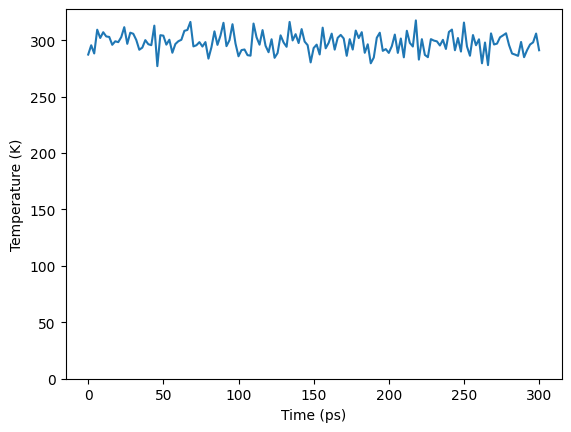

In [2]:
"""
Step1: Data loading from the trajectory file, and eqbr determination
"""
u=mda.Universe("final_nvt_equilibrated.data", "Water.lammpstrj", format="LAMMPSDUMP", lengthunit="A", timeunit="fs", dt=2, atom_style="id mol type q x y z")
Water=u.atoms
n_atoms=len(Water)
n_water=int(n_atoms/3)
n_frames=len(u.trajectory)
box=19.711200000000002

Oxygen=np.empty((n_frames, n_water, 3))
Hydrogen1=np.empty((n_frames, n_water, 3))
Hydrogen2=np.empty((n_frames, n_water, 3))

for i, ts in enumerate(u.trajectory):
    frame_coords=Water.positions

    Oxygen[i]=frame_coords[0::3, :]%box                                         #0::3: Start from 0, then take every 3rd atom from there (like 0, 3, 6)
    Hydrogen1[i]=frame_coords[1::3, :]%box
    Hydrogen2[i]=frame_coords[2::3, :]%box

T_data=pd.read_csv("log.lammps", sep=r"\s+", skiprows=107, nrows=151)
step=T_data["Step"].values
time=np.array(step*2/1000)                                                      #Time in ps
Temps=np.array(T_data["Temp"].values)
plt.ylim(0, np.max(Temps)+10)
plt.plot(time, Temps)
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.show()

In [33]:
"""
Step2: Important parameters for calculations
"""

n_skip=int(0*n_frames)                                                                                                #Data is already equilibrated, so we don't need to skip anything (from the temperature plot)!
print(n_skip)
dt=0.5                                                                                                                #Time step in fs
dump_freq=20                                                                                                        #Dump frequency in frames
time_bw_frames=dt*dump_freq
n_blocks=3
n_framesperblock=n_frames//n_blocks
traj_frac=0.33
maxlagtime=n_framesperblock*traj_frac*time_bw_frames
n_framesmaxlag=int(maxlagtime/time_bw_frames)
n_initial=int(n_framesperblock-n_framesmaxlag)                                                                        #Possible values of starting times

cutoff_angle=30                                                                                                       #H*O*O angle in degrees
cutoff_dist_OO=3.5                                                                                                    #O*-O distance in angstroms
cutoff_dist_OH=2.45                                                                                                   #O-H* distance in angstroms

#Minimum Image Convention function
def MIC(dirn):
    dir=dirn-np.round(dirn/box)*box
    return dir

0


In [34]:
"""
Step3: Actual Calculations, finding the correlations for every block, and then doing the block averages

np.newaxis is very important to create dimension mismatch, which leads to finding the properties of every pair easily!!
For instance, suppose H1 and H2 are N*3 arrays, storing every Hydrogen1 and Hydrogen2's positions, now H1[:, :]-H2[:, :] will give the displacement vectors between corresponding hydrogens, but H1[np.newaxis, :, :] creates an array of size 1*N*3
Using H1[np.newaxis, :, :]-H2[:, np.newaxis, :], we can get 1*N*3-N*1*3, and python will give an answer which ahs every atom's displacement vector from every other atom (and the resulting array will be of the size: N*N*3)

Whenever we find the norm of some array, let's say 2 3D of size (N1, N2, N3) along axis=2, the resulting array's size would be (N1, N2, ); which is not good, so we make the dimension as (N1, N2, 1) by using np.newaxis
There's one more way for this, while finding the norm, use np.linalg.norm(array, axis=2, keepdims=True)
"""
corr_dir=np.zeros((n_framesmaxlag, n_blocks))
time=np.arange(1, n_framesmaxlag)*(time_bw_frames/1000)                                                             #Time in ps (everything before this was in fs)
count=np.zeros((n_framesmaxlag, n_blocks))

H_bond1=np.full((n_frames, n_water), -1, dtype=np.int16)
H_bond2=np.full((n_frames, n_water), -1, dtype=np.int16)

norm_u_OO_H_bond1=np.zeros((n_frames, n_water, 3), dtype=np.float32)
norm_u_OO_H_bond2=np.zeros((n_frames, n_water, 3), dtype=np.float32)

#All the O-O distances
for t in range(n_frames):
    u_OO=MIC(Oxygen[t][np.newaxis, :, :]-Oxygen[t][:, np.newaxis, :])
    dist_OO=np.linalg.norm(u_OO, axis=2)

    #Normalized Vectors
    norm_u_OO=np.zeros_like(u_OO)
    np.divide(u_OO, dist_OO[:, :, np.newaxis], out=norm_u_OO, where=dist_OO[:, :, np.newaxis]>0.1)                  #This way of normalising is faster, and we're ensuring that the dist=0 (self) cases are not considered
    
    #Qualifying OO pairs (for H-bond) (and we shouldn't compare an O with itself)
    qual_OO=(dist_OO<=cutoff_dist_OO)&(dist_OO>0.1)

    #Check with H1
    #distance
    u_OH1=MIC(Hydrogen1[t][:, np.newaxis, :]-Oxygen[t][np.newaxis, :, :])
    dist_OH1=np.linalg.norm(u_OH1, axis=2)
    qual_OH1=(dist_OH1<=cutoff_dist_OH)

    #angle: Only the corresponding O and H are to be taken now!
    u_OH1_intra=MIC(Hydrogen1[t]-Oxygen[t])
    norm_u_OH1_intra=u_OH1_intra/np.linalg.norm(u_OH1_intra, axis=1)[:, np.newaxis]
    angle_OH1_OO=np.degrees(np.arccos(np.clip(np.einsum("id, ijd->ij", norm_u_OH1_intra, norm_u_OO), -1.0, 1.0)))
    qual_angle_OH1_OO=(angle_OH1_OO<=cutoff_angle)

    #All qualifications combined
    qual_H1Bond=(qual_OO)&(qual_angle_OH1_OO)&(qual_OH1)
    donorH1, acceptorO=np.where(qual_H1Bond)                                                                        

    if donorH1.size>0:
        _, unique_ind=np.unique(donorH1, return_index=True)                                                         #return_index=True helps us extract the positions of the first instance of the unique entity
        unique_ind=np.sort(unique_ind)
        #The acceptor O and H, along with the vectors
        d1, a1=donorH1[unique_ind], acceptorO[unique_ind]
        H_bond1[t, d1]=a1
        norm_u_OO_H_bond1[t, d1, :]=norm_u_OO[d1, a1, :]

    #Now, check with H2
    #distance
    u_OH2=MIC(Hydrogen2[t][:, np.newaxis, :]-Oxygen[t][np.newaxis, :, :])
    dist_OH2=np.linalg.norm(u_OH2, axis=2)
    qual_OH2=(dist_OH2<=cutoff_dist_OH)

    #angle: Only the corresponding O and H are to be taken now!
    u_OH2_intra=MIC(Hydrogen2[t]-Oxygen[t])
    norm_u_OH2_intra=u_OH2_intra/np.linalg.norm(u_OH2_intra, axis=1)[:, np.newaxis]
    angle_OH2_OO=np.degrees(np.arccos(np.clip(np.einsum("id, ijd->ij", norm_u_OH2_intra, norm_u_OO), -1.0, 1.0)))
    qual_angle_OH2_OO=(angle_OH2_OO<=cutoff_angle)

    #All qualifications combined
    qual_H2Bond=(qual_OO)&(qual_angle_OH2_OO)&(qual_OH2)
    donorH2, acceptorO=np.where(qual_H2Bond)

    if donorH2.size>0:
        _, unique_ind=np.unique(donorH2, return_index=True)
        unique_ind=np.sort(unique_ind)
        d2, a2=donorH2[unique_ind], acceptorO[unique_ind]
        H_bond2[t, d2]=a2
        norm_u_OO_H_bond2[t, d2, :]=norm_u_OO[d2, a2, :]

#The Actual TCF Part now!
for i in range(n_blocks):
    starting=i*n_framesperblock                     #This is the starting for a given block
    print(f"Block{i} started")
    for j in range(n_initial):
        ind_in=starting+j                           #This is the starting time
        
        #H-bonds at the initial time
        H1_0=H_bond1[ind_in]
        H2_0=H_bond2[ind_in]
        
        HB1=(H1_0!=-1)
        HB2=(H2_0!=-1)

        n_HB1_0=np.sum(HB1)
        n_HB2_0=np.sum(HB2)

        u_OO1_in=norm_u_OO_H_bond1[ind_in]
        u_OO2_in=norm_u_OO_H_bond2[ind_in]

        for k in range(n_framesmaxlag):
            ind_fi=ind_in+k
            HB1=HB1&(H_bond1[ind_fi]==H1_0)         #Same partner: Why the same? Because we want to just find the frame reorientation and it's happening b/w jumps, so partner remains the same!!
            HB2=HB2&(H_bond2[ind_fi]==H2_0)

            u_OO1_fi=norm_u_OO_H_bond1[ind_fi]
            u_OO2_fi=norm_u_OO_H_bond2[ind_fi]
            
            #count[k,i]+=n_HB1_0+n_HB2_0
            count[k,i]+=np.sum(HB1)+np.sum(HB2)

            #Check if any partner exists or not! If there's any, then find the <> of P2 of the correlation. Also, using a bool array inside [] makes the index=the indices where the bool array returns True
            if np.any(HB1):
                cos_t1=np.sum(u_OO1_in[HB1]*u_OO1_fi[HB1], axis=1)
                P2_1=0.5*(3*(cos_t1**2)-1)
                corr_dir[k,i]+=np.sum(P2_1)

            if np.any(HB2):
                cos_t2=np.sum(u_OO2_in[HB2]*u_OO2_fi[HB2], axis=1)
                P2_2=0.5*(3*(cos_t2**2)-1)
                corr_dir[k, i]+=np.sum(P2_2)

Block0 started
Block1 started
Block2 started


Frame Time for block 0=3.69ps (Integral Method)
Frame Time for block 0=6.48ps (exp fit)
Frame Time for block 1=2.48ps (Integral Method)
Frame Time for block 1=5.46ps (exp fit)
Frame Time for block 2=3.11ps (Integral Method)
Frame Time for block 2=5.03ps (exp fit)

Mean Frame Time (integral, ps): 3.09
Stdev Frame Time (integral, ps): 0.49

Mean Frame Time (exp, ps): 5.66
Stdev Frame Time (exp, ps): 0.61


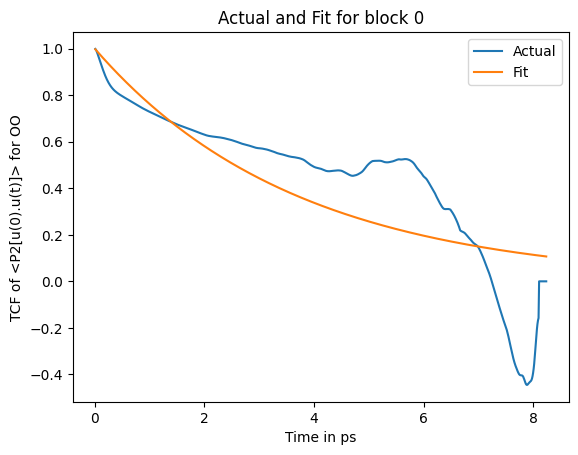

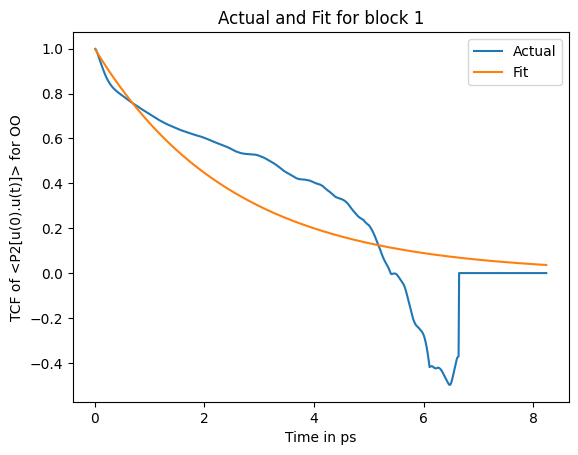

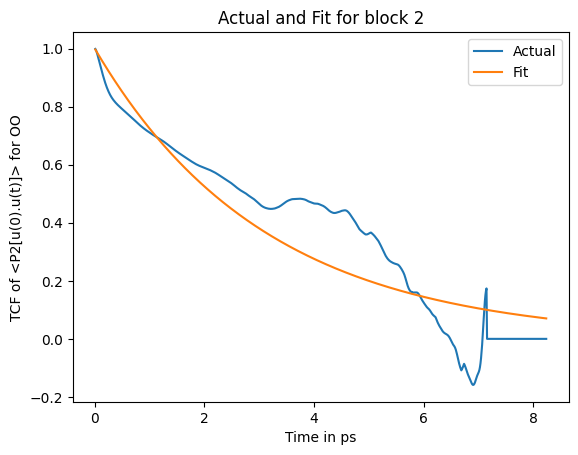

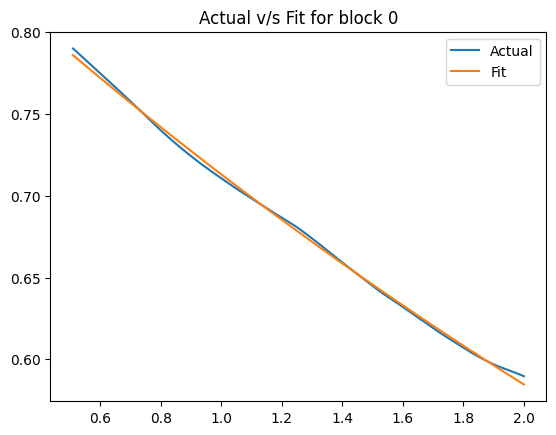

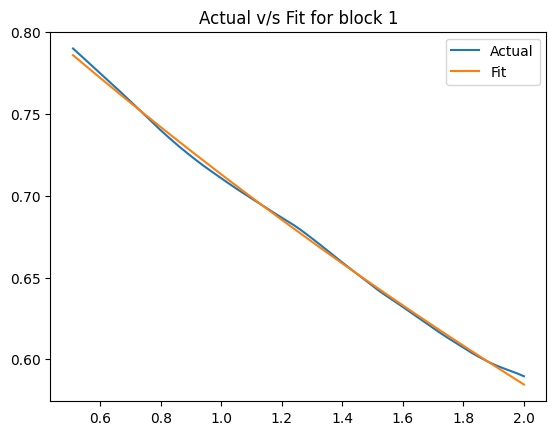

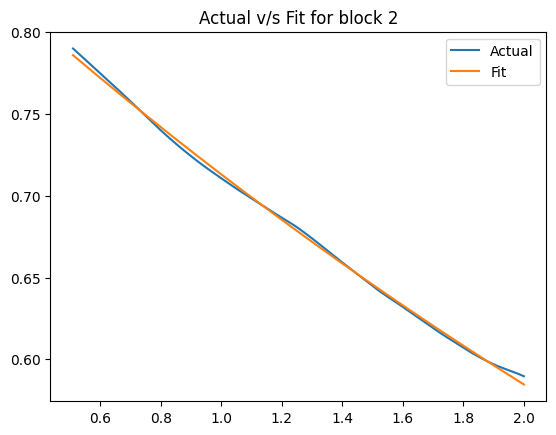

In [38]:
countA=count.copy()
countA[countA==0]=1                                             #So that division isn't problematic

corr_dir2=corr_dir/countA

corr_avg=np.mean(corr_dir2, axis=-1)
corr_avg_len=len(corr_avg)
block_jump_time=np.zeros(n_blocks)
tau_exp=np.zeros(n_blocks)
fit_exp=np.zeros(n_blocks)
inter=np.zeros(n_blocks)

for i in range(n_blocks):
    y_block=corr_dir2[1:, i]
    x_block=time[:len(y_block)]
    
    jump_time=np.trapezoid(y_block, x_block)
    block_jump_time[i]=jump_time

    print(f"Frame Time for block {i}={block_jump_time[i]:.2f}ps (Integral Method)")

    frames_for_2=int(2000/time_bw_frames)
    frames_for_lib=int(0.5*1000/time_bw_frames)

    t0=time[frames_for_lib:frames_for_2]
    y_exp=np.log(y_block[frames_for_lib:frames_for_2])
    x_exp=t0
    fit_exp[i], inter[i]=np.polyfit(x_exp, y_exp, deg=1)
    tau_exp[i]=-1.0/fit_exp[i]
    print(f"Frame Time for block {i}={tau_exp[i]:.2f}ps (exp fit)")

print(f'\nMean Frame Time (integral, ps): {np.mean(block_jump_time):.2f}')
print(f'Stdev Frame Time (integral, ps): {np.std(block_jump_time):.2f}')

print(f'\nMean Frame Time (exp, ps): {np.mean(tau_exp):.2f}')
print(f'Stdev Frame Time (exp, ps): {np.std(tau_exp):.2f}')

for i in range(n_blocks):
    t_plot=time
    corr_fit=np.exp(-1.0*t_plot/block_jump_time[i])
    plt.plot(t_plot, corr_dir2[1:1+len(t_plot), i], label="Actual")
    plt.plot(t_plot, corr_fit, label="Fit")
    plt.xlabel("Time in ps")
    plt.ylabel("TCF of <P2[u(0).u(t)]> for OO")
    plt.title(f"Actual and Fit for block {i}")
    plt.legend()
    plt.show()

for i in range(n_blocks):
    frames_for_2=int(2000/time_bw_frames)
    frames_for_lib=int(0.5*1000/time_bw_frames)

    t0=time[frames_for_lib:frames_for_2]
    y_exp=np.log(y_block[frames_for_lib:frames_for_2])
    x_exp=t0
    fit_exp[i], inter[i]=np.polyfit(x_exp, y_exp, deg=1)
    tau_exp[i]=-1.0/fit_exp[i]
    y_exp_fit=np.exp(inter[i]-x_exp/tau_exp[i])
    plt.title(f"Actual v/s Fit for block {i}")
    plt.plot(x_exp, y_block[frames_for_lib:frames_for_2], label="Actual")
    plt.plot(x_exp, y_exp_fit, label="Fit")
    plt.legend()
    plt.show()

200
50
5.59


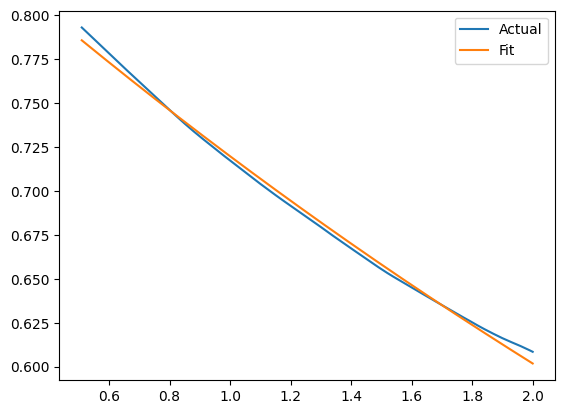

In [37]:
frames_for_2=int(2000/time_bw_frames)
frames_for_lib=int(0.5*1000/time_bw_frames)

print(frames_for_2)
print(frames_for_lib)

i0=0
for i in range(len(corr_avg)):
    if(corr_avg[i]<=0):
        i0=i
        break

t0=time[frames_for_lib:frames_for_2]
y_exp=np.log(corr_avg[frames_for_lib:frames_for_2])
x_exp=t0
fit_exp, inter=np.polyfit(x_exp, y_exp, deg=1)
tau_exp=-1.0/fit_exp
print(f"{tau_exp:.2f}")
y_exp_fit=np.exp(inter-x_exp/tau_exp)
plt.plot(x_exp, corr_avg[frames_for_lib:frames_for_2], label="Actual")
plt.plot(x_exp, y_exp_fit, label="Fit")
plt.legend()
plt.show()